# Contract Clause Extractor

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/document-intelligence/contract-extractor/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=document-intelligence/contract-extractor/demo.ipynb)

> Turn a 3-day legal read into a 30-second clause + risk triage.

A legal reviewer's first pass on any contract is mechanical: find the termination terms,
the liability cap, the payment terms, the auto-renewal trap - and notice what's *missing*.
This notebook does that pass automatically.

**What this notebook covers**
1. The clause cue patterns a reviewer scans for first
2. Extracting clauses + party names + effective date with zero LLM calls (regex heuristics)
3. Flagging risk per clause and detecting missing expected clauses
4. A risk-profile bar chart for the contract
5. Upgrading to Claude for paraphrased clauses
6. Try your own contract


## Step 1 - Why a heuristic first pass

Every Claude call costs money and latency. For triage across a stack of contracts, a
deterministic regex pass is the right altitude: instant, free, and good enough to surface
the clauses a human must read. We reserve the LLM for contracts where clauses are
paraphrased in unusual language. Below is the core logic, self-contained so this notebook
runs with no API key and no imports from `app.py`.

In [1]:
from __future__ import annotations

import re
from dataclasses import dataclass, field


@dataclass
class Clause:
    clause_type: str
    text: str
    risk: str = "low"   # low | medium | high
    note: str = ""


@dataclass
class ContractReview:
    parties: list = field(default_factory=list)
    effective_date: str = ""
    clauses: list = field(default_factory=list)
    missing_clauses: list = field(default_factory=list)

    def risk_counts(self):
        counts = {"low": 0, "medium": 0, "high": 0}
        for c in self.clauses:
            counts[c.risk] = counts.get(c.risk, 0) + 1
        return counts


# Clause types a reviewer scans for first, with cue patterns + a default risk weight.
CLAUSE_CUES = {
    "Termination": (re.compile(r"\b(terminat\w+|cancel\w+|expire|notice period)\b", re.I), "medium"),
    "Liability": (re.compile(r"\b(liabilit\w+|indemnif\w+|hold harmless|damages)\b", re.I), "high"),
    "Confidentiality": (re.compile(r"\b(confidential\w*|non-disclosure|proprietary information)\b", re.I), "low"),
    "Payment": (re.compile(r"\b(payment|fee|invoice|net \d+|compensation|\$[\d,]+)\b", re.I), "medium"),
    "Governing Law": (re.compile(r"\b(governing law|jurisdiction|governed by the laws)\b", re.I), "low"),
    "Auto-Renewal": (re.compile(r"\b(auto\w*[- ]?renew\w*|automatically renew|evergreen)\b", re.I), "high"),
    "Intellectual Property": (re.compile(r"\b(intellectual property|work product|ownership of|license to)\b", re.I), "medium"),
    "Warranty": (re.compile(r"\b(warrant\w+|as is|fitness for a particular purpose)\b", re.I), "medium"),
}

# Clauses flagged as RISKY when missing entirely.
EXPECTED_CLAUSES = ["Termination", "Liability", "Confidentiality", "Payment", "Governing Law"]


def _split_sentences(text: str):
    return [s.strip() for s in re.split(r"(?<=[.!?])\s+", text.strip()) if s.strip()]


def _extract_parties(text: str):
    m = re.search(r"between\s+(.+?)\s+and\s+(.+?)[\.,\n]", text, re.I)
    return [m.group(1).strip(), m.group(2).strip()] if m else []


def _extract_date(text: str):
    m = re.search(
        r"\b(?:dated|effective(?:\s+as\s+of)?|entered into on)\s+([A-Z][a-z]+ \d{1,2}, \d{4}|\d{4}-\d{2}-\d{2})",
        text, re.I)
    return m.group(1) if m else ""


def heuristic_review(contract: str) -> ContractReview:
    """Scan each sentence for clause cues, flag risk + missing clauses. No LLM."""
    clauses, seen = [], set()
    for sent in _split_sentences(contract):
        for ctype, (pattern, risk) in CLAUSE_CUES.items():
            if pattern.search(sent):
                clauses.append(Clause(clause_type=ctype, text=sent, risk=risk))
                seen.add(ctype)
    missing = [c for c in EXPECTED_CLAUSES if c not in seen]
    return ContractReview(_extract_parties(contract), _extract_date(contract), clauses, missing)


print("Core logic loaded. Tracking", len(CLAUSE_CUES), "clause types.")


Core logic loaded. Tracking 8 clause types.


## Step 2 - A sample contract

A short Master Services Agreement with the clauses you'd expect - plus a sneaky
auto-renewal and a one-sided liability cap, and *no* governing-law clause.

In [2]:
SAMPLE_CONTRACT = """\
This Master Services Agreement ("Agreement") is entered into on March 15, 2026,
between Acme Analytics Inc. and Beta Retail LLC.

1. Services. Acme will provide data engineering services as described in each Statement of Work.

2. Payment. Beta shall pay all invoices Net 30. Fees total $48,000 per quarter.

3. Term and Termination. This Agreement begins on the effective date and remains in
effect for twelve months. Either party may terminate with 30 days written notice.

4. Auto-Renewal. This Agreement will automatically renew for successive one-year terms
unless either party gives notice of non-renewal at least 90 days before the renewal date.

5. Confidentiality. Each party agrees to keep the other's proprietary information confidential.

6. Limitation of Liability. Acme's total liability shall not exceed the fees paid in the
prior three months. Beta agrees to indemnify and hold harmless Acme against third-party claims.

7. Intellectual Property. All work product created under this Agreement is owned by Beta,
with Acme retaining a license to its pre-existing tools.
"""

print(SAMPLE_CONTRACT[:200], "...")


This Master Services Agreement ("Agreement") is entered into on March 15, 2026,
between Acme Analytics Inc. and Beta Retail LLC.

1. Services. Acme will provide data engineering services as described  ...


## Step 3 - Run the review

One call returns parties, effective date, every matched clause with a risk flag, and the
list of expected clauses that are missing.

In [3]:
review = heuristic_review(SAMPLE_CONTRACT)

print("Parties:        ", " <-> ".join(review.parties))
print("Effective date: ", review.effective_date)
print("Clauses found:  ", len(review.clauses))
print("Missing clauses:", ", ".join(review.missing_clauses) or "none")
print()
for c in review.clauses:
    mark = {"high": "[HIGH]", "medium": "[MED ]", "low": "[LOW ]"}[c.risk]
    print(f"{mark} {c.clause_type}")


Parties:         Acme Analytics Inc. <-> Beta Retail LLC
Effective date:  March 15, 2026
Clauses found:   13
Missing clauses: Governing Law

[MED ] Payment
[MED ] Payment
[MED ] Termination
[MED ] Termination
[HIGH] Auto-Renewal
[HIGH] Auto-Renewal
[LOW ] Confidentiality
[LOW ] Confidentiality
[HIGH] Liability
[HIGH] Liability
[HIGH] Liability
[MED ] Intellectual Property
[MED ] Intellectual Property


## Step 4 - Visualize the risk profile

A single bar chart tells a reviewer where to spend their attention: how many clauses fall
in each risk band, plus a callout for anything missing.

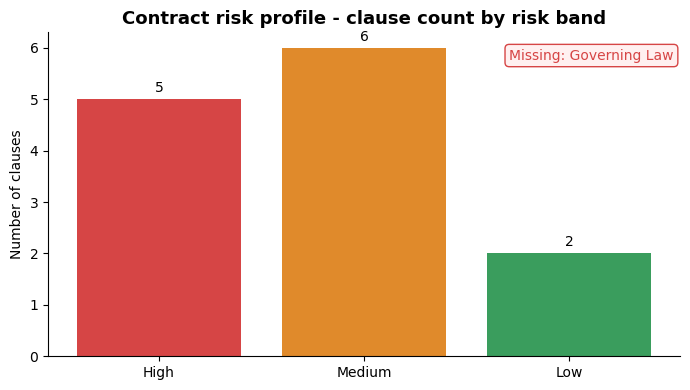

In [4]:
import matplotlib.pyplot as plt

counts = review.risk_counts()
bands = ["high", "medium", "low"]
values = [counts[b] for b in bands]
colors = ["#d64545", "#e08a2b", "#3a9d5d"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar([b.capitalize() for b in bands], values, color=colors)
ax.set_title("Contract risk profile - clause count by risk band", fontsize=13, weight="bold")
ax.set_ylabel("Number of clauses")
ax.bar_label(bars, padding=3)
ax.spines[["top", "right"]].set_visible(False)

missing_txt = "Missing: " + (", ".join(review.missing_clauses) or "none")
ax.text(0.99, 0.95, missing_txt, transform=ax.transAxes, ha="right", va="top",
        fontsize=10, color="#d64545",
        bbox=dict(boxstyle="round", fc="#fff0f0", ec="#d64545"))

plt.tight_layout()
plt.savefig("risk_profile.png", dpi=120, bbox_inches="tight")
plt.show()


## Summary

| Output | Value |
|--------|-------|
| Parties | Acme Analytics Inc. <-> Beta Retail LLC |
| Effective date | March 15, 2026 |
| High-risk clauses | Liability, Auto-Renewal |
| Missing clause | **Governing Law** (no jurisdiction named) |

The two items a human reviewer should jump to: the **auto-renewal** with a 90-day
non-renewal window (easy to miss, expensive to forget) and the **liability cap** that
favors one party. The tool found both in under a second - and flagged that the contract
never names a governing jurisdiction.

## Upgrade to Claude (optional)

The regex pass catches clauses worded conventionally. For contracts where clauses are
paraphrased ("neither side will be on the hook beyond..."), swap in Claude. Set
`ANTHROPIC_API_KEY` and the production `extractor.py` routes to the LLM automatically -
same `ContractReview` shape, so charts and the Streamlit app work unchanged.

In [5]:
# import os, json, anthropic
#
# def llm_review(contract: str, api_key: str) -> ContractReview:
#     client = anthropic.Anthropic(api_key=api_key)
#     resp = client.messages.create(
#         model="claude-sonnet-4-5",
#         max_tokens=1500,
#         messages=[{"role": "user", "content":
#             "Extract contract clauses with risk levels. Return JSON only.\n" + contract}],
#     )
#     data = json.loads(resp.content[0].text)
#     return ContractReview(
#         data.get("parties", []), data.get("effective_date", ""),
#         [Clause(**c) for c in data.get("clauses", [])],
#         data.get("missing_clauses", []),
#     )
#
# review = llm_review(SAMPLE_CONTRACT, os.environ["ANTHROPIC_API_KEY"])


In [6]:
# --- Try your own contract ---
# my_contract = """
# Paste any agreement text here...
# """
# my_review = heuristic_review(my_contract)
# for c in my_review.clauses:
#     print(c.risk.upper(), "-", c.clause_type)
# print("Missing:", my_review.missing_clauses)


---

Part of [**phoebe-the-builder**](https://github.com/phoebefu6/phoebe-the-builder) -
Day 33 of the 60-day FDE portfolio.

**Run the full app:**
```bash
pip install -r requirements.txt
streamlit run app.py
```
The Streamlit version adds PDF upload (via `pypdf`), expandable clause cards, and a
high-risk-count metric at the top.